In [1]:
import numpy as np
def standard_1d_fft(row):
  if(len(row)==1):
    return row
  N = len(row)
  even = row[0::2]
  odd = row[1::2]
  evenpart = standard_1d_fft(even)
  oddpart = standard_1d_fft(odd)
  twiddle = np.exp(-2*1j*np.pi*np.arange(N//2)/N)
  firsthalf = evenpart + twiddle*oddpart
  secondhalf = evenpart - twiddle*oddpart
  return np.concat([firsthalf,secondhalf])
def standard_2d_fft(img):
  rowresult = [standard_1d_fft(row) for row in img]
  fftresult = [standard_1d_fft(row) for row in np.transpose(rowresult)]
  return np.transpose(fftresult)
def standard_1d_ifft(row):
  if(len(row)==1):
    return row
  N = len(row)
  even = row[0::2]
  odd = row[1::2]
  evenpart = standard_1d_ifft(even)
  oddpart = standard_1d_ifft(odd)
  twiddle = np.exp(2*1j*np.pi*np.arange(N//2)/N)
  firsthalf = evenpart + twiddle*oddpart
  secondhalf = evenpart - twiddle*oddpart
  return np.concat([firsthalf,secondhalf])
def standard_2d_ifft(img):
  rowresult = [standard_1d_ifft(row) for row in img]
  ifftresult = [standard_1d_ifft(row) for row in np.transpose(rowresult)]
  return np.transpose(ifftresult)

In [2]:
def fft_ifft(image):
  import numpy as np
  import matplotlib.pyplot as plt
  import cv2
  import os
  img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
  print(img)
  fft_result = standard_2d_fft(img)
  print(fft_result)
  ifft_result = standard_2d_ifft(fft_result)/(img.shape[0]*img.shape[1])
  print(ifft_result)
  ifft_image = np.real(ifft_result)
  ifft_image = np.round(ifft_image).astype(np.uint8)
  plt.figure()
  plt.imshow(ifft_image, cmap='gray')
  plt.title("Q1_Resultant Image")
  plt.axis("off")
  plt.show()
  directory = os.path.dirname(image)
  filename = os.path.splitext(os.path.basename(image))[0]
  output_path = os.path.join(
        directory,
        filename + "_ifft.png"
    )
  cv2.imwrite(output_path, ifft_image)

In [3]:
def visualize_spectrum(image_path):
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    fft_result = standard_2d_fft(img)
    magnitude = np.abs(fft_result)
    magnitude_log = np.log(1 + magnitude)
    magnitude_shifted = np.fft.fftshift(magnitude_log)
    phase = np.angle(fft_result)
    phase_shifted = np.fft.fftshift(phase)
    directory = os.path.dirname(image_path)
    filename = os.path.splitext(os.path.basename(image_path))[0]
    magnitude_path = os.path.join(
        directory,
        filename + "_magnitude.png"
    )

    phase_path = os.path.join(
        directory,
        filename + "_phase.png"
    )
    plt.figure()
    plt.imshow(magnitude_shifted, cmap='gray')
    plt.title("Magnitude Spectrum")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(magnitude_path, bbox_inches="tight")
    plt.close()
    plt.figure()
    plt.imshow(phase_shifted, cmap='gray')
    plt.title("Phase Spectrum")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(phase_path, bbox_inches="tight")
    plt.close()
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(magnitude_shifted, cmap='gray')
    plt.title("Magnitude Spectrum")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(phase_shifted, cmap='gray')
    plt.title("Phase Spectrum")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Magnitude spectrum saved at:", magnitude_path)
    print("Phase spectrum saved at:", phase_path)

In [4]:
def transform(image):
  import cv2
  import math,os
  import matplotlib.pyplot as plt
  import numpy as np
  img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
  img1 = np.zeros((img.shape[0],img.shape[1]),dtype=complex)
  ifftimg = np.zeros((img.shape[0],img.shape[1]),dtype=complex)
  for i in range(img.shape[0]):
    for j in range(img.shape[1]):
      img1[i][j] = img[i][j]*math.pow(-1,i+j)
  fft_img = standard_2d_fft(img1)
  conjnummatrix = np.conjugate(fft_img)
  ifft_image = standard_2d_ifft(conjnummatrix)/(img.shape[0]*img.shape[1])
  for i in range(img.shape[0]):
    for j in range(img.shape[1]):
      ifftimg[i][j] = np.real(ifft_image[i][j])*math.pow(-1,i+j) + 1j*np.imag(ifft_image[i][j])
  ifft_ = np.real(ifftimg)
  ifft = np.round(ifft_).astype(np.uint8)
  plt.figure()
  plt.imshow(ifft, cmap='gray')
  plt.title("Q2 Resultant Image")
  plt.axis("off")
  plt.show()
  directory = os.path.dirname(image)
  filename = os.path.splitext(os.path.basename(image))[0]
  output_path = os.path.join(
        directory,
        filename + "_transformed.png"
    )
  cv2.imwrite(output_path, ifft)


[[121  76  32 ... 145 158 163]
 [117  76  39 ... 139 148 153]
 [ 93  76  61 ... 116 110 109]
 ...
 [ 96 114 138 ...  93  91  90]
 [125 135 147 ...  96  95  95]
 [140 141 140 ...  90  89  89]]
[[33679996.              +0.j          -773726.66497423 +290071.9443664j
    487420.03439395 -205832.079976j   ...
   1108399.54953796  +96420.39342965j   487420.03439395 +205832.079976j
   -773726.66497423 -290071.9443664j ]
 [ -266920.05055295 +209372.1329957j   1845467.29597978 -404669.14929436j
     68456.64574514 +257132.9255115j  ...
  -1357715.74023381 +212817.03659934j  -481328.831533   +605017.20264801j
    870251.28864445 +156453.64831775j]
 [ -323260.30030722+2112434.26085142j  -718526.67925593 -579971.78191927j
   -190163.98046376 -588317.05186363j ...
    672088.32089564 +130704.95496806j   191557.40197964 -778270.34976057j
   -960734.58811279 -698799.16194111j]
 ...
 [  166454.44000602 -680016.17444714j  -515318.58252565 +529386.07067095j
    131248.41291529 -242332.00340919j ...
   

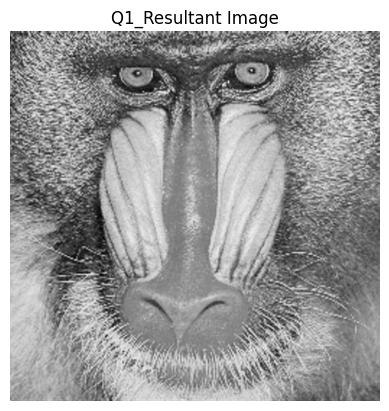

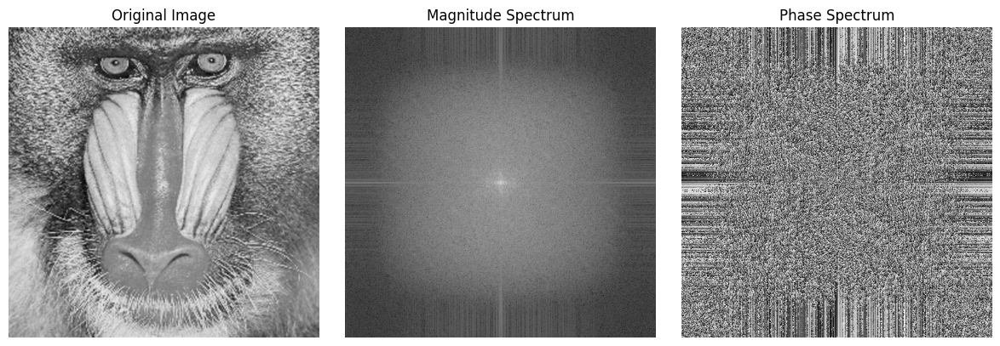

Magnitude spectrum saved at: /content/mandril_gray_magnitude.png
Phase spectrum saved at: /content/mandril_gray_phase.png


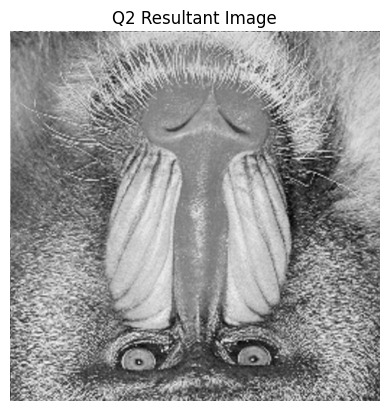

[[162 162 162 ... 170 155 128]
 [162 163 162 ... 169 155 128]
 [162 162 162 ... 171 155 128]
 ...
 [ 43  43  50 ... 103 100  98]
 [ 44  43  55 ... 104 105 108]
 [ 44  44  55 ... 104 105 108]]
[[ 3.25180920e+07      +0.j         -4.55545398e+05+2393164.15223234j
   1.53654929e+06-1135716.72321208j ... -2.37000838e+05 -635186.61908059j
   1.53654929e+06+1135716.72321208j -4.55545398e+05-2393164.15223234j]
 [-3.03280491e+04-1224169.11293672j -1.58760006e+06+1593728.22864459j
  -1.10624456e+06  +78223.84841062j ...  6.51950508e+05 +813575.33546623j
  -3.55634297e+05 +447413.93889256j  3.54124781e+04 +946166.85205496j]
 [-4.49586952e+05 -163238.46406949j -2.75337768e+05 -133253.87986196j
   6.67582274e+05 -455654.53499874j ...  3.52826083e+05 +926922.76157898j
  -7.23456745e+05 -175760.50184759j  8.21541300e+05  -64081.42136266j]
 ...
 [ 5.16185645e+05 -215057.91739999j  7.35436214e+05 +708331.62452249j
  -5.26403899e+05 -200832.94963198j ...  9.93083710e+05 +115584.83845363j
   1.33504640e

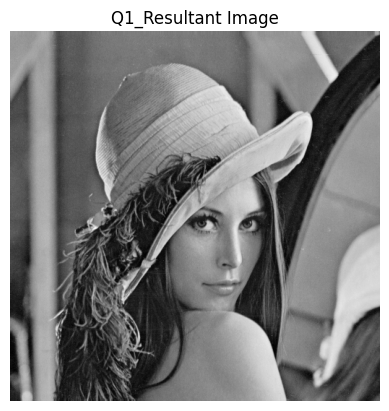

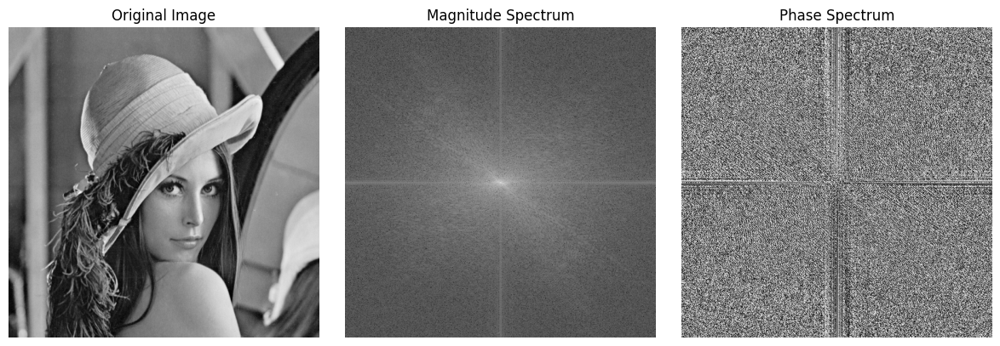

Magnitude spectrum saved at: /content/lena_gray_512_magnitude.png
Phase spectrum saved at: /content/lena_gray_512_phase.png


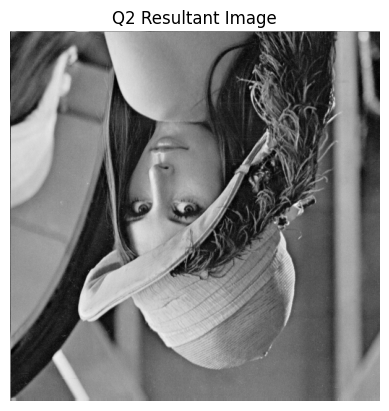

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[ 392021.            +0.j            1559.26774024-27567.85513564j
  -104773.30030668-25032.32964703j ... -257887.67153834-23026.85544058j
  -104773.30030668+25032.32964703j    1559.26774024+27567.85513564j]
 [-378302.93645888 -3473.06778078j    2834.75795177+16419.89259272j
   107890.78136243+25397.88306574j ...  244538.24252705+42296.77623561j
    95388.89672655-22289.27965435j   -6730.00225287-37708.47391715j]
 [ 338790.168882   +6336.24642533j   -6121.39559216 -5407.81409383j
  -104645.05516059-23325.05403624j ... -215584.85959643-59254.53121074j
   -80524.65258695+17550.82351705j   12232.34018435+45760.25115873j]
 ...
 [-278177.59803627 +8122.82178533j  -17558.71391209+50839.48457717j
    61575.88504959+11455.4456679j  ...  200140.36349064-24754.37684502j
    95622.42084156-19090.67910702j    8120.28521672 +4402.82762017j]
 [ 338790.168882   -6336.24642533j   12

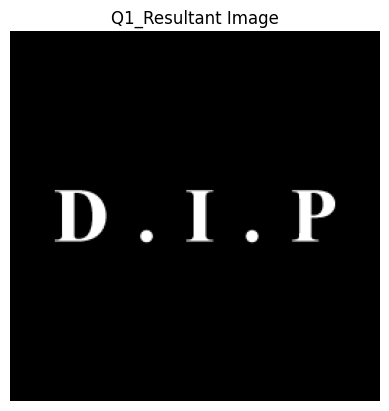

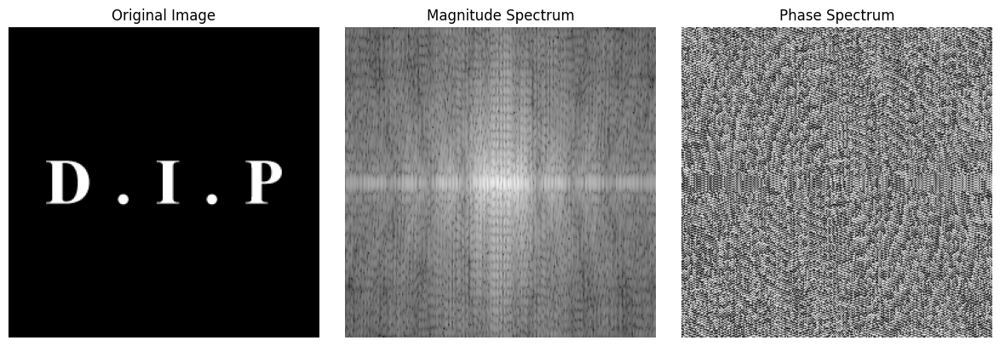

Magnitude spectrum saved at: /content/dip_magnitude.png
Phase spectrum saved at: /content/dip_phase.png


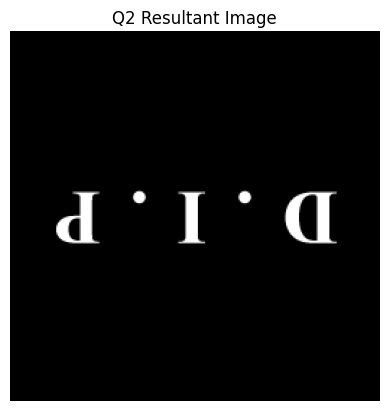

[[156 158 160 ... 152 152 152]
 [156 157 159 ... 152 152 152]
 [158 156 156 ... 152 152 152]
 ...
 [120 123 127 ... 121 113 111]
 [121 123 125 ... 121 113 111]
 [121 123 126 ... 121 113 111]]
[[31015448.              +0.j          1915614.48384335+4666509.44805024j
   1522956.8925852 -1376699.78781353j ...
    124984.00123175+1117119.00038066j  1522956.8925852 +1376699.78781354j
   1915614.48384335-4666509.44805024j]
 [ 2753674.05750265-3380888.45463556j -2403576.23157522-3046886.57163755j
  -1141119.79694933+2290646.52359711j ...
   -342949.12312449 -545908.61283968j   500781.4942542  +926346.32400679j
   -906492.53193294 +870546.06097577j]
 [  732182.78834343-2002832.57214479j  -868162.05524177 +919577.61352439j
    333582.30532497 +487515.97400917j ...
   -405846.08920517 +523266.72145924j  -200494.2336406  +327527.42227627j
    735505.28754136 +389318.14953807j]
 ...
 [ -667107.28520811 +356303.34467445j  -413052.82664714 -231158.30317709j
    199700.85589409 +538060.48200335j ...


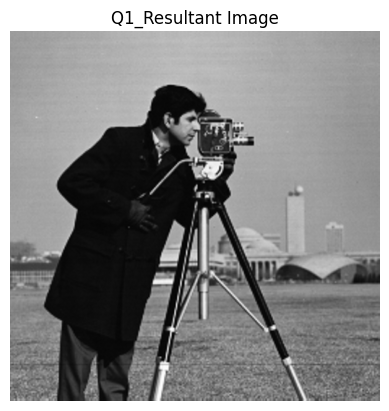

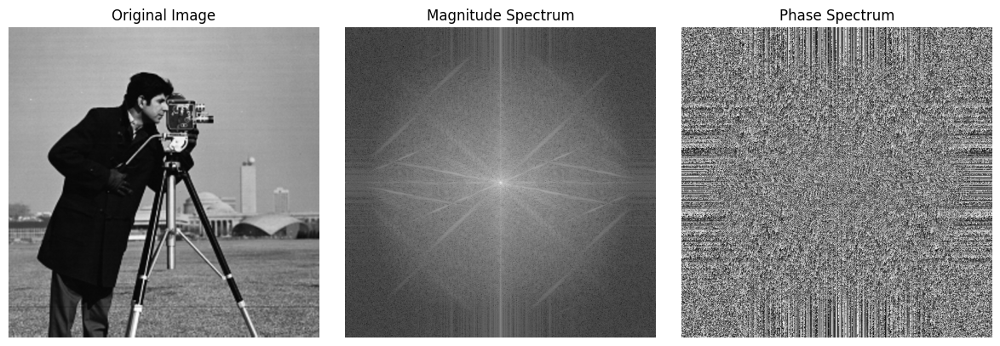

Magnitude spectrum saved at: /content/cameraman_magnitude.png
Phase spectrum saved at: /content/cameraman_phase.png


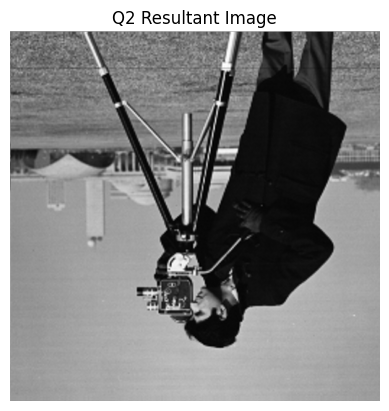

[[ 37 127 130 ... 185 181 150]
 [ 35 122 131 ... 188 181 125]
 [ 38 101 105 ... 178 165  91]
 ...
 [ 25  38  42 ... 162 161 144]
 [ 27  48  36 ... 155 159 140]
 [ 27  38  36 ... 164 164 144]]
[[ 3.26029030e+07      +0.j         -5.79673070e+06+2353826.84693476j
   1.72040759e+06 +316669.92772839j ...  1.59364903e+06+1147032.5405594j
   1.72040759e+06 -316669.92772839j -5.79673070e+06-2353826.84693476j]
 [ 2.21854922e+06-1942278.38018875j -3.12574483e+05+2286707.117909j
   3.46196239e+05 -150860.9088451j  ... -8.98700477e+05 -462781.18834558j
  -6.07948891e+05   -6327.45243869j  4.98465160e+05+1281200.83316898j]
 [-1.14665056e+06+2321891.46042485j  6.09189337e+05  +67616.49960359j
   2.28692420e+05 +309099.03689168j ... -3.13943705e+05 -882251.7187337j
  -2.68055559e+05 +326346.5811434j   2.00300522e+06 +112380.55068116j]
 ...
 [ 1.98510017e+04+1770731.25883557j -4.60049342e+05-1083097.22649148j
  -1.79691397e+05 -246580.86751018j ... -1.34949324e+05 +871225.41327784j
   1.10184298e+05 

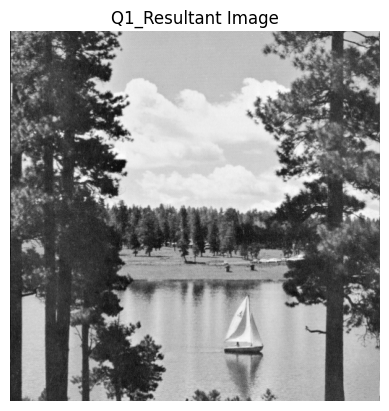

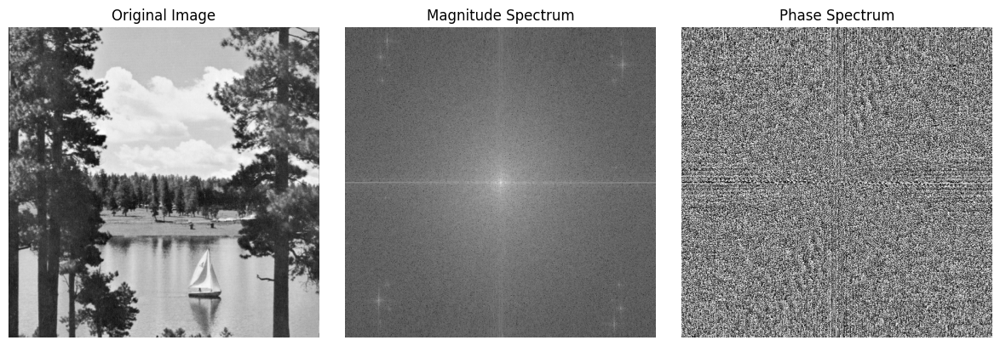

Magnitude spectrum saved at: /content/lake_magnitude.png
Phase spectrum saved at: /content/lake_phase.png


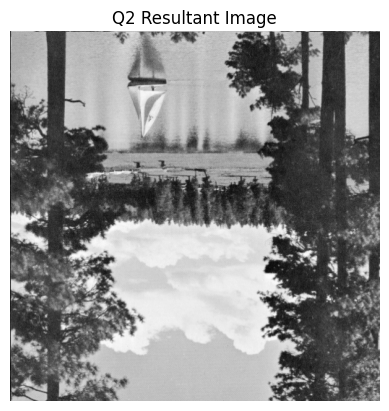

[[ 93  81  85 ... 162 134  85]
 [105  96  94 ... 127 106 104]
 [ 89  85 111 ... 100  91  97]
 ...
 [ 76  84  89 ...  75  97 105]
 [ 89  96  97 ...  77  70  80]
 [118 113  98 ... 102  68  69]]
[[ 2.99184130e+07      +0.j          3.44085587e+05-3861139.38290535j
   4.87054956e+05-2215025.18174458j ... -3.39570841e+05+1137931.64709963j
   4.87054956e+05+2215025.18174458j  3.44085587e+05+3861139.38290535j]
 [ 8.24443005e+05-2739957.94888852j  4.40090175e+05 -249205.4955339j
  -5.41128302e+05 +271606.70390681j ... -2.59579244e+04 -148742.23655364j
  -1.22989864e+05 +136867.22495358j -1.76631914e+05+1021964.80489637j]
 [-2.39455579e+06+1175216.16172318j  4.48648060e+05 +611147.85747031j
  -2.59509177e+05 +643661.40490456j ... -4.99736187e+05 -500840.05575592j
  -1.52684305e+05 +566762.3187442j  -1.05752643e+05-1434731.85908716j]
 ...
 [ 1.61217619e+06  -27347.56004173j -5.10889758e+05  +11032.00773094j
   8.28045422e+04 +800843.65885015j ...  1.91196517e+05  +85124.88231552j
  -1.59656002e+

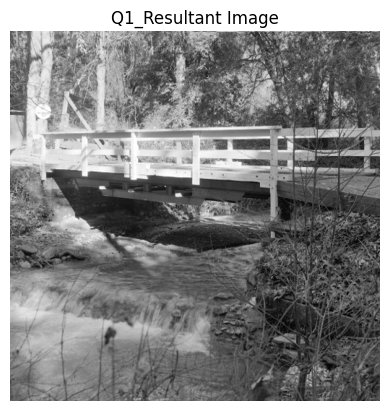

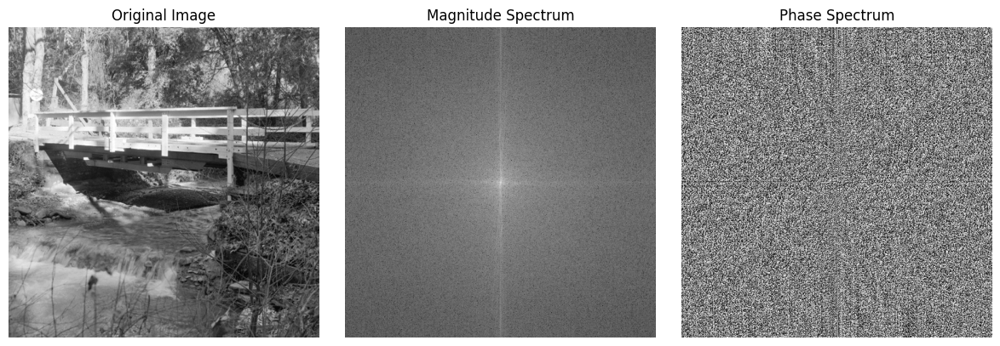

Magnitude spectrum saved at: /content/walkbridge_magnitude.png
Phase spectrum saved at: /content/walkbridge_phase.png


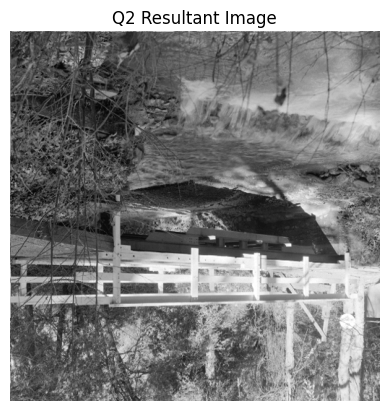

[[150 152 155 ... 134 130 133]
 [148 144 144 ... 135 129 129]
 [153 145 136 ... 138 127 127]
 ...
 [122 124 124 ... 149 145 150]
 [122 126 124 ... 137 111 118]
 [123 130 122 ... 122 106 104]]
[[ 2.92656690e+07      +0.j          3.20232620e+05+2789254.02148436j
  -1.07726104e+06 -251711.31543514j ...  4.76058260e+05 -496661.42233349j
  -1.07726104e+06 +251711.31543514j  3.20232620e+05-2789254.02148436j]
 [-1.97050798e+05 -339311.68245588j  2.20320130e+06 -746444.82853497j
  -4.67445544e+05 -564676.19487529j ...  1.47371340e+05 +152285.35517736j
   1.79217912e+06-1044556.88268092j -3.38509045e+05 -610718.94607505j]
 [-1.83971198e+06 +403299.06558539j  6.60004100e+05 +820691.50229754j
   5.17797699e+05 -217239.26646524j ...  9.21717217e+05 -124350.89700129j
   3.47120083e+05 -673999.1139257j   6.08780037e+05 +508430.78664094j]
 ...
 [ 2.69358112e+05+1302499.7072463j   1.12296864e+05 -416691.05523747j
   1.15534591e+06 -638863.35578718j ... -1.32740108e+04 -315339.73936747j
   1.82653713e

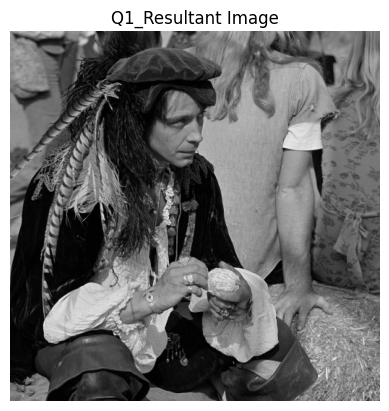

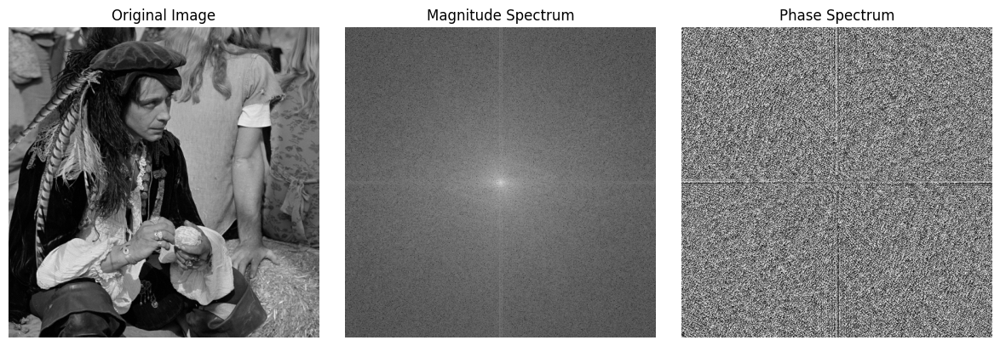

Magnitude spectrum saved at: /content/pirate_magnitude.png
Phase spectrum saved at: /content/pirate_phase.png


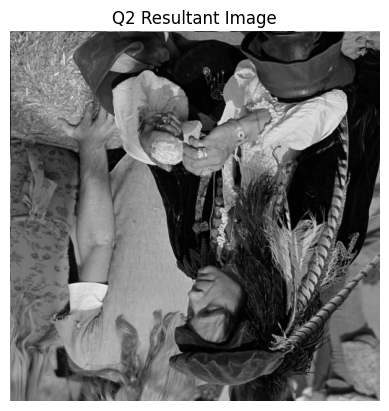

[[121 121 124 ... 122 121 124]
 [117 112 113 ... 125 122 130]
 [114 115 117 ... 125 128 125]
 ...
 [151 152 144 ...  98 133 143]
 [151 155 146 ...  95 131 152]
 [154 155 155 ...  97 120 159]]
[[31693371.              +0.j         -1683347.18266813 +388312.40381406j
    320135.89064704 +248603.26296707j ...
   -408512.96805715 +245377.88412124j   320135.89064704 -248603.26296707j
  -1683347.18266813 -388312.40381406j]
 [  428771.60576557-2873602.73736923j  -247405.35861777-1897832.0059467j
    568217.29192994 +442785.83183163j ...
    385251.2031401   -62769.06030513j  -946943.23022054 +877856.30658679j
   -500613.87355566 +266143.34832803j]
 [ -319049.08196673 +670849.05648528j   816685.53058214-2054492.8301844j
    697402.24904611 -608444.46335373j ...
   -424725.78346739 -341354.31817831j  -158266.39564672 +239435.11172853j
    374650.78899592 +137983.16523807j]
 ...
 [ 1138956.80760585 +387956.24221866j  -545725.06025763 +926409.16567292j
   -157494.39420137 +125306.28853888j ...
  

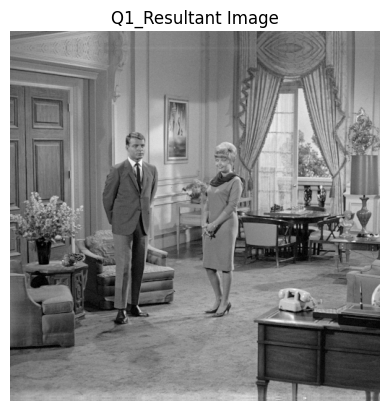

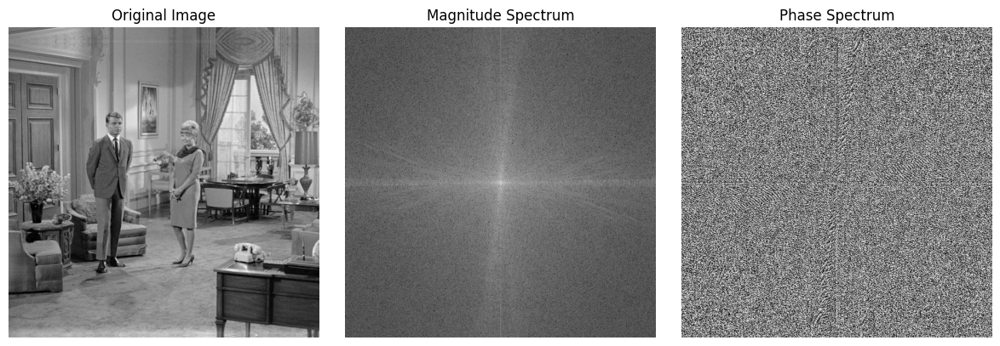

Magnitude spectrum saved at: /content/livingroom_magnitude.png
Phase spectrum saved at: /content/livingroom_phase.png


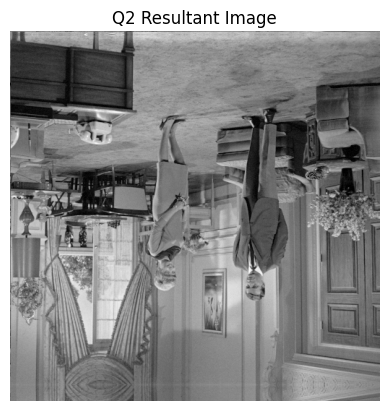

[[193 185 178 ... 165 164 147]
 [191 195 194 ... 178 157 139]
 [194 197 193 ... 190 156 141]
 ...
 [215 212 209 ... 205 208 213]
 [217 211 208 ... 191 189 191]
 [213 211 211 ... 184 176 150]]
[[ 4.66671930e+07      +0.j          9.82359821e+05 +722888.59399854j
   2.71220816e+05+1064898.66688867j ...  7.05317453e+05 -866943.87584679j
   2.71220816e+05-1064898.66688867j  9.82359821e+05 -722888.59399854j]
 [ 1.59602504e+06-1615017.34347863j -2.79373239e+04 -215287.71555515j
   3.03393922e+05-1371831.44670359j ...  2.64684065e+05  +84442.34093897j
  -3.51420608e+05+1290481.82032953j -9.25384143e+05+2865730.68301196j]
 [-6.12291670e+05 +141885.93332871j -2.05594063e+05 -443731.49766666j
   3.58211000e+05 +452422.88995576j ...  1.04760050e+04 +745346.76517526j
  -3.29431729e+05 +592215.64291718j -1.64681061e+06  -25393.59794277j]
 ...
 [-2.65013683e+05 -599736.69950953j -5.28971167e+05 +633956.7202978j
   6.45941211e+04 +621275.08731766j ...  3.72322389e+05  +67055.08144637j
   1.78277680e+

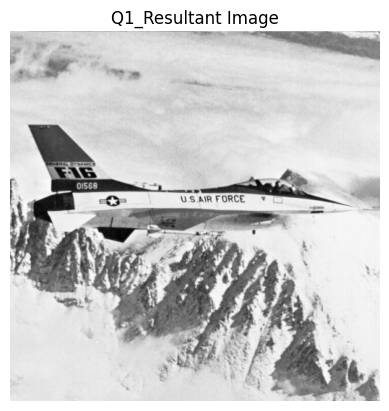

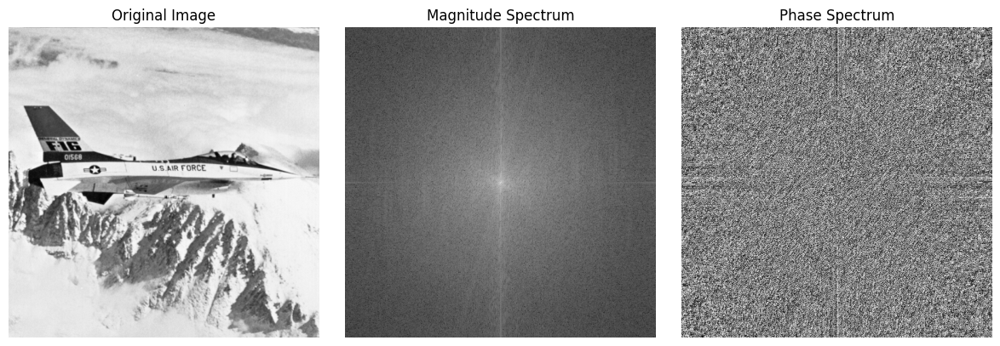

Magnitude spectrum saved at: /content/jetplane_magnitude.png
Phase spectrum saved at: /content/jetplane_phase.png


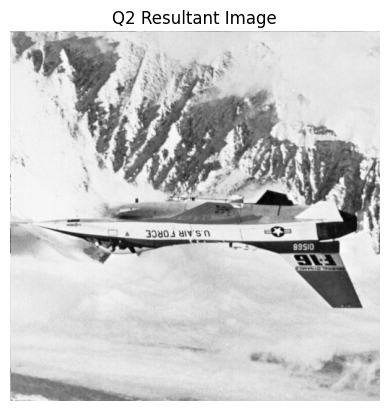

In [5]:
import os
image_files = [
    os.path.join('/content', filename)
    for filename in os.listdir('/content')
    if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))
]
for image in image_files:
  fft_ifft(image)
  visualize_spectrum(image)
  transform(image)

In [6]:
  import cv2
  image = '/content/dip.tif'
  img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
  print(img)
  ij = np.fft.fft2(img)
  print(ij)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[ 392021.            +0.j            1559.26774024-27567.85513564j
  -104773.30030668-25032.32964703j ... -257887.67153834-23026.85544058j
  -104773.30030668+25032.32964703j    1559.26774024+27567.85513564j]
 [-378302.93645888 -3473.06778078j    2834.75795177+16419.89259272j
   107890.78136243+25397.88306574j ...  244538.24252705+42296.77623561j
    95388.89672655-22289.27965435j   -6730.00225287-37708.47391715j]
 [ 338790.168882   +6336.24642533j   -6121.39559216 -5407.81409383j
  -104645.05516059-23325.05403624j ... -215584.85959643-59254.53121074j
   -80524.65258695+17550.82351705j   12232.34018435+45760.25115873j]
 ...
 [-278177.59803627 +8122.82178533j  -17558.71391209+50839.48457717j
    61575.88504959+11455.4456679j  ...  200140.36349064-24754.37684502j
    95622.42084156-19090.67910702j    8120.28521672 +4402.82762017j]
 [ 338790.168882   -6336.24642533j   12

In [7]:
import os
import zipfile
from google.colab import files

output_zip = "/content/all_images.zip"

with zipfile.ZipFile(output_zip, "w", zipfile.ZIP_DEFLATED) as zipf:
    for filename in os.listdir("/content"):
        if filename.lower().endswith((
            ".jpg", ".jpeg", ".png", ".tif", ".tiff"
        )):
            file_path = os.path.join("/content", filename)
            zipf.write(file_path, arcname=filename)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import zipfile

all_images = "/content/all_images.zip"

with zipfile.ZipFile(all_images, 'r') as zip_file:
    image_files = [
        f for f in zip_file.namelist()
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))
    ]

print("Number of images:", len(image_files))

Number of images: 45
